In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/modeling_table_pm25_met.csv", parse_dates=["date"])
df.head()


,State Name,County Name,Site Num,Latitude,Longitude,Arithmetic Mean,Units of Measure,Sample Duration,Observation Count,source_file,date,met_station,temp,dewpoint,sea_level_pressure,wind_speed,precipitation,snow_depth
0,District Of Columbia,District of Columbia,41,38.895572,-76.958072,7.625000,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-01,DCA,1.15,-7.454167,-16.512500,1031.658333,7730,46.291667
1,District Of Columbia,District of Columbia,41,38.895572,-76.958072,9.625000,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-02,DCA,1.15,-7.683333,-18.929167,1034.458333,-3279,46.375000
2,District Of Columbia,District of Columbia,41,38.895572,-76.958072,17.041667,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-03,DCA,1.15,-4.975000,-13.862500,1026.762500,-17248,14.500000
3,District Of Columbia,District of Columbia,41,38.895572,-76.958072,8.250000,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-04,DCA,1.15,-3.120833,-9.516667,758.362500,5960,77.500000
4,District Of Columbia,District of Columbia,41,38.895572,-76.958072,2.416667,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-05,DCA,1.15,-8.454167,-19.987500,1017.025000,7130,78.041667


## Ridge was used because the data seems correlated, therefore providing a stable, interpretable reference model

In [3]:

#MINIMAL CLEANING
# Target
y_col = "Arithmetic Mean"

# Keep only rows with met features present
feature_cols = ["temp", "dewpoint", "wind_speed", "sea_level_pressure", "precipitation"]
available = [c for c in feature_cols if c in df.columns]

df = df.dropna(subset=[y_col] + available).copy()

# Basic time features
df["month"] = df["date"].dt.month
df["dow"] = df["date"].dt.dayofweek

available += ["month", "dow"]

print("Rows after dropna:", len(df))
print("Date range:", df["date"].min(), df["date"].max())

Rows after dropna: 33723
Date range: 2018-01-01 00:00:00 2024-12-31 00:00:00


In [4]:
#TRAIN/TEST SPLIT BY TIME
train = df[df["date"].dt.year.isin([2018, 2019, 2022, 2023])]
test  = df[df["date"].dt.year == 2024]

X_train = train[available]
y_train = train[y_col]
X_test  = test[available]
y_test  = test[y_col]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (22104, 7) Test: (11619, 7)


In [5]:
#RIDGE BASELINE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
print("Ridge MAE:", mae)
print("Ridge RMSE:", rmse)

Ridge MAE: 3.1310068455203837
Ridge RMSE: 4.1077873667911415


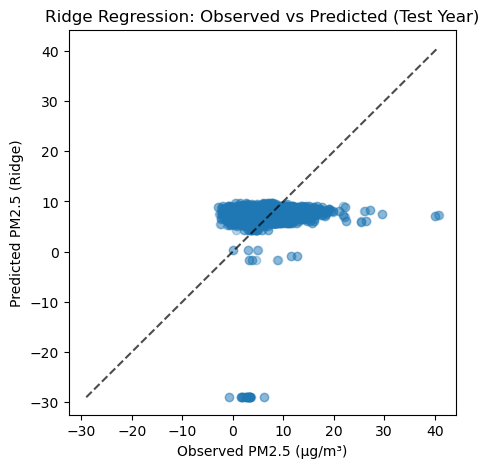

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.scatter(y_test, pred, alpha=0.3)

# 1:1 reference line
lims = [
    min(y_test.min(), pred.min()),
    max(y_test.max(), pred.max())
]
plt.plot(lims, lims, "k--", alpha=0.7)

plt.xlabel("Observed PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (Ridge)")
plt.title("Ridge Regression: Observed vs Predicted (Test Year)")

plt.show()


## Now the question is, how much predictive power can we gain by allowing nonlinear relationships and interactions, compared to a linear baseline?

In [8]:
#TREE BASELINE (RANDOM FOREST)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=0,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = mean_squared_error(y_test, pred_rf) ** 0.5
print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 2.878761655065117
RF RMSE: 3.738095771936801


In [9]:
results = pd.DataFrame({
    "model": ["Ridge", "RandomForest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
})
results


,model,MAE,RMSE
0,Ridge,3.131007,4.107787
1,RandomForest,2.878762,3.738096


## Random Forest baseline is used here to capture nonlinear interactions and thresholds in meteorological drivers of PM 2.5, using the same time-based split and evaluation metrics as the linear baseline to quantify the added value of model complexity

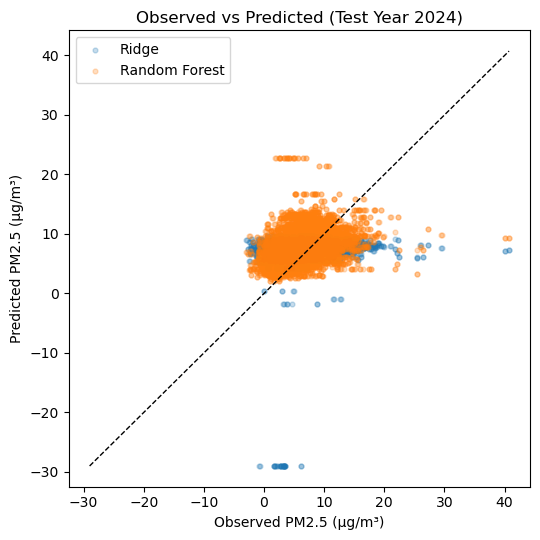

In [11]:

plt.figure(figsize=(5.5, 5.5))

# Ridge
plt.scatter(y_test, pred, alpha=0.25, label="Ridge", s=12)

# Random Forest
plt.scatter(y_test, pred_rf, alpha=0.25, label="Random Forest", s=12)

# 1:1 line
lims = [
    min(y_test.min(), pred.min(), pred_rf.min()),
    max(y_test.max(), pred.max(), pred_rf.max()),
]
plt.plot(lims, lims, "k--", linewidth=1)

plt.xlabel("Observed PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Observed vs Predicted (Test Year 2024)")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# Clip predictions for visualization only
pred_plot = np.clip(pred, 0, None)
pred_rf_plot = np.clip(pred_rf, 0, None)

# Training observations
train_ts = train[["date", y_col]].copy()
train_ts["split"] = "train"

# Test observations + predictions
test_ts = test[["date", y_col]].copy()
test_ts["pred_ridge"] = pred_plot
test_ts["pred_rf"] = pred_rf_plot
test_ts["split"] = "test"

# Combine
plot_df = pd.concat([train_ts, test_ts], ignore_index=True)
#aggregate medians
daily = plot_df.groupby(["date", "split"]).median().reset_index()


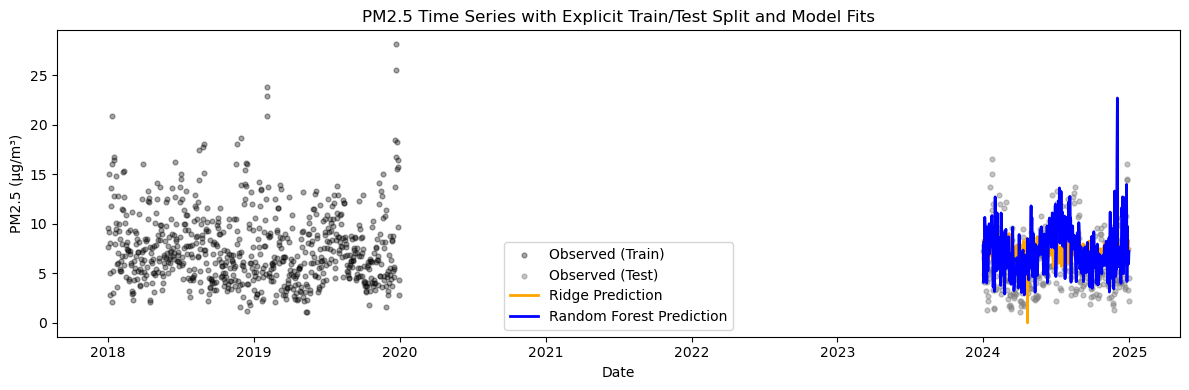

In [13]:
#plot everything
plt.figure(figsize=(12, 4))

# Training data (black scatter)
train_daily = daily[daily["split"] == "train"]
plt.scatter(
    train_daily["date"],
    train_daily[y_col],
    color="black",
    alpha=0.35,
    s=12,
    label="Observed (Train)"
)

# Test data (gray scatter)
test_daily = daily[daily["split"] == "test"]
plt.scatter(
    test_daily["date"],
    test_daily[y_col],
    color="gray",
    alpha=0.45,
    s=12,
    label="Observed (Test)"
)

# Ridge fit (orange line)
plt.plot(
    test_daily["date"],
    test_daily["pred_ridge"],
    color="orange",
    linewidth=2,
    label="Ridge Prediction"
)

# Random Forest fit (blue line)
plt.plot(
    test_daily["date"],
    test_daily["pred_rf"],
    color="blue",
    linewidth=2,
    label="Random Forest Prediction"
)

plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 Time Series with Explicit Train/Test Split and Model Fits")
plt.legend()
plt.tight_layout()
plt.savefig('../figures/ts_train_test_models.png')
plt.show()


## Black points denote training observations (2018–2019, 2022–2023), while gray points denote held-out test observations (2024). Ridge regression captures the seasonal baseline but underestimates high-P2.5 events, whereas the Random Forest model better tracks nonlinear variability in the unseen test year.

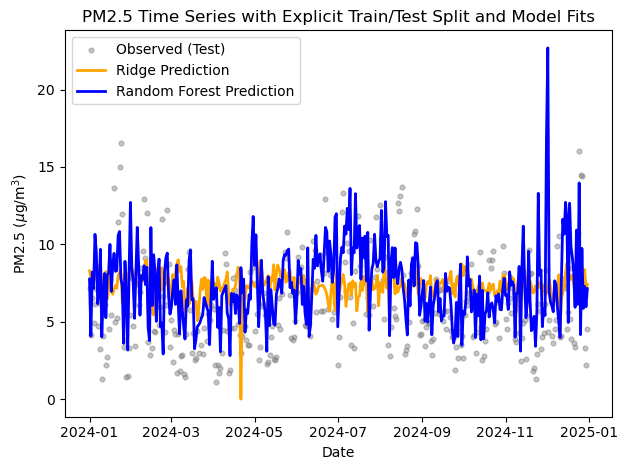

In [15]:
# Test data (gray scatter)
test_daily = daily[daily["split"] == "test"]
plt.scatter(
    test_daily["date"],
    test_daily[y_col],
    color="gray",
    alpha=0.45,
    s=12,
    label="Observed (Test)"
)

# Ridge fit (orange line)
plt.plot(
    test_daily["date"],
    test_daily["pred_ridge"],
    color="orange",
    linewidth=2,
    label="Ridge Prediction"
)

# Random Forest fit (blue line)
plt.plot(
    test_daily["date"],
    test_daily["pred_rf"],
    color="blue",
    linewidth=2,
    label="Random Forest Prediction"
)
plt.xlabel("Date")
plt.ylabel(r"PM2.5 ($\mu$g/m$^3$)")
plt.title("PM2.5 Time Series with Explicit Train/Test Split and Model Fits")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/pm25_timeseries_train_test_models.png", dpi=300)
plt.show()

## The time-series comparison indicates a strong seasonal modulation of PM2.5 driven by meteorological conditions, with nonlinear interactions—more frequent in summer—leading to episodic high-PM2.5 events that are better captured by the Random Forest model.

In [17]:
# Build daily observed PM2.5 table for seasonal analysis
ts_daily = (
    df.groupby("date")[y_col]
      .median()   # robust across sites
      .to_frame()
)

# Ensure datetime index
ts_daily.index = pd.to_datetime(ts_daily.index)

# Monthly means
#showing elevated means in the summer months
ts_daily["month"] = ts_daily.index.month
ts_daily.groupby("month")[y_col].mean()


month
1     7.434197
2     7.905276
3     5.946676
4     5.554741
5     6.582922
6     7.619481
7     8.373168
8     8.254624
9     5.969902
10    6.010556
11    6.532306
12    8.116673
Name: Arithmetic Mean, dtype: float64

In [18]:
from sklearn.metrics import r2_score

r2_ridge = r2_score(y_test, pred)
r2_rf = r2_score(y_test, pred_rf)

print(f"Ridge R$^2$ (test): {r2_ridge:.2f}")
print(f"RF R$^2$ (test): {r2_rf:.2f}")


Ridge R$^2$ (test): -0.37
RF R$^2$ (test): -0.14


In [19]:
# --- Add persistence (lag) features safely + retrain Ridge/RF + report metrics ---
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assumes you already have:
# df (loaded modeling_table_pm25_met.csv), y_col = "Arithmetic Mean", and `available` = base feature list
# Example base features in `available`: ["temp","dewpoint","wind_speed","sea_level_pressure","precipitation","month","dow"]

# 1) Ensure proper ordering for lag construction
df = df.sort_values(["Site Num", "date"]).copy()

# 2) Create lag features within each monitoring site (no leakage across sites)
df["pm25_lag1"] = df.groupby("Site Num")[y_col].shift(1)

# Past-only rolling mean:
# shift(1) ensures we don't use today's PM2.5 in the rolling window
df["pm25_roll3"] = (
    df.groupby("Site Num")[y_col]
      .shift(1)
      .rolling(window=3, min_periods=3)
      .mean()
)

# 3) Drop rows where lag features are missing (first day(s) per site)
df_lagged = df.dropna(subset=["pm25_lag1", "pm25_roll3"]).copy()

# 4) Rebuild feature list
available_lag = list(available) + ["pm25_lag1", "pm25_roll3"]

# 5) Time-aware split (same as before)
train = df_lagged[df_lagged["date"].dt.year.isin([2018, 2019, 2022, 2023])]
test  = df_lagged[df_lagged["date"].dt.year == 2024]

X_train = train[available_lag]
y_train = train[y_col]
X_test  = test[available_lag]
y_test  = test[y_col]

print("Train:", X_train.shape, "Test:", X_test.shape)

# 6) Ridge baseline (with scaling)
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

# 7) Random Forest baseline (no scaling needed)
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=0,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# 8) Metrics
def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results_lag = pd.DataFrame([
    report("Ridge + lags", y_test, pred_ridge),
    report("RF + lags", y_test, pred_rf),
])

results_lag


Train: (22062, 9) Test: (11613, 9)


,model,MAE,RMSE,R2
0,Ridge + lags,1.443573,2.186099,0.611579
1,RF + lags,1.497327,2.213450,0.601799


### KEY TAKEAWAYS:
## 1) Linear models capture the seasonal baseline structure of PM2.5 variability.
## 2) Nonlinear models better capture episodic high-PM2.5 events driven by meteorological interactions.
## 3) Meteorology alone improves pointwise prediction error but does not explain out-of-sample variance. Incorporating temporal persistence is essential for predictive skill, consistent with the multi-day atmospheric lifetime of fine particulate matter